# Detection diagnostics — Ground-truth MIDI vs. Basic Pitch

Goal: stop treating "77.6% note F1" as one number. Align GuitarSet ground-truth notes
against Basic Pitch output, split every note into **matched / missed (false negative) /
spurious (false positive)**, then slice the errors to see *where* they come from:

1. **Precision vs. recall**, overall and split solo vs. comp
2. **Register** — which pitches get missed / invented
3. **Octave harmonics** — what share of false positives are +12 / +24 ghosts of real notes
4. **Polyphony** — recall on chords vs. single notes
5. **Onset timing & fragmentation** — misses caused by alignment, not the model
6. **Amplitude threshold sweep** — how many misses are just under the cutoff

Each section ends with a takeaway. Run top to bottom; set your paths in the config cell.

In [1]:
# Basic Pitch install (Colab-safe). Run once.
import sys, subprocess, pkgutil, zipimport
if not hasattr(pkgutil, "ImpImporter"):
    pkgutil.ImpImporter = zipimport.zipimporter
def _run(c): print("$"," ".join(c)); subprocess.check_call(c)
try:
    import librosa, mir_eval  # noqa
    from basic_pitch.inference import predict as basic_pitch_predict  # noqa
    print("Basic Pitch + librosa available.")
except Exception:
    _run([sys.executable,"-m","pip","install","-q","--upgrade","pip","wheel","setuptools==80.9.0"])
    _run([sys.executable,"-m","pip","install","-q","librosa>=0.10","soundfile","resampy==0.4.2","onnxruntime","pretty_midi","mir_eval"])
    _run([sys.executable,"-m","pip","install","-q","--no-deps","basic-pitch==0.4.0"])
    if not hasattr(pkgutil, "ImpImporter"): pkgutil.ImpImporter = zipimport.zipimporter
    import librosa, mir_eval  # noqa
    from basic_pitch.inference import predict as basic_pitch_predict  # noqa
    print("Installed Basic Pitch + librosa.")

$ /usr/bin/python3 -m pip install -q --upgrade pip wheel setuptools==80.9.0
$ /usr/bin/python3 -m pip install -q librosa>=0.10 soundfile resampy==0.4.2 onnxruntime pretty_midi mir_eval
$ /usr/bin/python3 -m pip install -q --no-deps basic-pitch==0.4.0


/usr/local/lib/python3.12/dist-packages/resampy/filters.py:50: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Installed Basic Pitch + librosa.


In [6]:
from pathlib import Path
from collections import defaultdict
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from basic_pitch.inference import predict as basic_pitch_predict
warnings.filterwarnings("ignore")

IN_COLAB = Path("/content").exists()
if IN_COLAB:
    try:
        from google.colab import drive; drive.mount("/content/drive")
    except Exception as e:
        print("Drive mount skipped:", e)

# ============================ CONFIG ============================
# Where GuitarSet annotations (.jams) and audio live. Edit to match your Drive.
DATA_ROOT_CANDIDATES = [
    Path("/content/drive/MyDrive/Capstone/FullGuitarSetData"),
    Path("/content/drive/MyDrive/Capstone/GuitarSet"),
    Path("/content/drive/MyDrive/Capstone"),
]
AUDIO_ROOT_CANDIDATES = [
    Path("/content/drive/MyDrive/Capstone/FullGuitarSetData"),
    Path("/content/drive/MyDrive/Capstone/GuitarSet/audio_mono-mic"),
    Path("/content/drive/MyDrive/Capstone"),
]
AUDIO_EXTENSIONS = [".wav", ".mp3", ".flac", ".m4a"]

OPEN_STRING_MIDI = [40, 45, 50, 55, 59, 64]
MAX_FRET = 22

# Detection / matching knobs
ONSET_TOL = 0.05            # seconds; a GT note and a BP note match if same pitch and |Δonset| <= this
AMP_THRESHOLD = 0.30        # the cutoff your pipeline uses (note kept if amplitude >= this)
BP_MIN_MIDI, BP_MAX_MIDI = 40, 88
# Detect at a lower onset/frame threshold than default (0.5) so we capture near-threshold
# candidates too — needed for the amplitude sweep and "recoverable miss" analysis.
BP_ONSET_THRESHOLD = 0.30
BP_FRAME_THRESHOLD = 0.30

MAX_RECORDINGS = 60       # None = all; set e.g. 60 for a faster first pass

OUTPUT_DIR = (Path("/content/drive/MyDrive/Capstone/outputs/detection_diag")
              if IN_COLAB else Path("detection_diag_out"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BP_CACHE = OUTPUT_DIR / "bp_raw_cache"; BP_CACHE.mkdir(parents=True, exist_ok=True)
print("Output dir:", OUTPUT_DIR.resolve())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output dir: /content/drive/MyDrive/Capstone/outputs/detection_diag


In [7]:
# ============================ Load GuitarSet ground-truth notes (note_midi only) ============================
def find_jams_dir(root):
    for c in [root/"JamsFiles", root/"Annotations", root/"GuitarSet"/"Annotations",
              root/"FullGuitarSetData"/"JamsFiles", root/"FullGuitarSetData"/"Annotations", root]:
        if c.exists() and list(c.glob("*.jams")): return c
    if root.exists():
        for m in root.rglob("*.jams"): return m.parent
    return None

JAMS_DIR = None
for r in DATA_ROOT_CANDIDATES:
    if r.exists():
        d = find_jams_dir(r)
        if d: JAMS_DIR = d; break
if JAMS_DIR is None:
    raise FileNotFoundError("No .jams found. Fix DATA_ROOT_CANDIDATES.")
JAMS_FILES = sorted(JAMS_DIR.glob("*.jams"))
print(f"Found {len(JAMS_FILES)} JAMS files in {JAMS_DIR}")

def _ann_rows(ann):
    d = ann.get("data", [])
    if isinstance(d, list): return d
    if isinstance(d, dict):
        n = len(d.get("time", []))
        return [{k: d.get(k, [None]*n)[i] for k in ["time","duration","value","confidence"]} for i in range(n)]
    return []

def parse_notes(path):
    jam = json.load(open(path))
    notes = []
    for ann in jam.get("annotations", []):
        if ann.get("namespace") != "note_midi": continue
        ds = ann.get("annotation_metadata", {}).get("data_source", "")
        try: s = int(ds)
        except Exception: s = None
        for r in _ann_rows(ann):
            v = r.get("value")
            midi = (v.get("midi_note") or v.get("note") or v.get("pitch")) if isinstance(v, dict) else v
            if midi is None: continue
            notes.append({"start": float(r.get("time", 0.0)),
                          "duration": float(r.get("duration", 0.0) or 0.0),
                          "midi": int(round(float(midi)))})
    notes.sort(key=lambda x: (x["start"], x["midi"]))
    return {"recording": path.stem, "notes": notes,
            "is_solo": path.stem.endswith("_solo"), "is_comp": path.stem.endswith("_comp")}

records = [parse_notes(p) for p in JAMS_FILES]
print("Parsed records:", len(records), "| total GT notes:", sum(len(r["notes"]) for r in records))

Found 360 JAMS files in /content/drive/MyDrive/Capstone/FullGuitarSetData/JamsFiles
Parsed records: 360 | total GT notes: 62476


In [8]:
# ============================ Pair recordings with audio ============================
def find_audio_files(roots):
    by_stem = {}
    for root in roots:
        root = Path(root)
        if not root.exists(): continue
        for ext in AUDIO_EXTENSIONS:
            for p in root.rglob(f"*{ext}"): by_stem.setdefault(p.stem, p)
    return by_stem

AUDIO_BY_STEM = find_audio_files(AUDIO_ROOT_CANDIDATES)
print(f"Found {len(AUDIO_BY_STEM)} audio files.")

def find_audio_for_record(rec):
    name = rec["recording"]
    for stem in [name, f"{name}_mic", f"{name}_hex",
                 name.replace("_solo","_solo_mic"), name.replace("_comp","_comp_mic"),
                 name.replace("_solo","_solo_hex"), name.replace("_comp","_comp_hex")]:
        if stem in AUDIO_BY_STEM: return AUDIO_BY_STEM[stem]
    return None

paired = [(r, find_audio_for_record(r)) for r in records]
paired = [(r, ap) for r, ap in paired if ap is not None]
if MAX_RECORDINGS: paired = paired[:MAX_RECORDINGS]
print(f"Paired {len(paired)} records with audio (analyzing these).")

Found 365 audio files.
Paired 60 records with audio (analyzing these).


In [9]:
# ============================ Basic Pitch (raw, low threshold, cached) ============================
def run_basic_pitch_raw(audio_path, use_cache=True):
    cache = BP_CACHE / f"{Path(audio_path).stem}_bpraw.csv"
    if use_cache and cache.exists():
        df = pd.read_csv(cache)
        return df.to_dict("records") if len(df) else []
    _, _, events = basic_pitch_predict(str(audio_path), onset_threshold=BP_ONSET_THRESHOLD, frame_threshold=BP_FRAME_THRESHOLD)
    notes = [{"start": float(e[0]), "end": float(e[1]), "duration": float(e[1]-e[0]),
              "midi": int(round(float(e[2]))), "amplitude": float(e[3])} for e in events]
    notes.sort(key=lambda n: (n["start"], n["midi"]))
    pd.DataFrame(notes).to_csv(cache, index=False)
    return notes

def pipeline_filter(raw):
    return [n for n in raw if n["amplitude"] >= AMP_THRESHOLD and BP_MIN_MIDI <= n["midi"] <= BP_MAX_MIDI]

In [10]:
# ============================ Alignment + helpers ============================
def match_detection(gt_notes, bp_notes, tol=ONSET_TOL):
    """Greedy one-to-one match by pitch + onset. Returns matches, missed (GT-only), spurious (BP-only)."""
    cands = []
    for pi, p in enumerate(bp_notes):
        for gi, g in enumerate(gt_notes):
            if int(p["midi"]) != int(g["midi"]): continue
            dt = abs(float(p["start"]) - float(g["start"]))
            if dt <= tol: cands.append((dt, pi, gi))
    cands.sort(key=lambda x: x[0])
    up, ug, matches = set(), set(), []
    for dt, pi, gi in cands:
        if pi in up or gi in ug: continue
        up.add(pi); ug.add(gi)
        matches.append({"gi": gi, "pi": pi, "midi": gt_notes[gi]["midi"], "onset_error": dt,
                        "bp_amp": bp_notes[pi].get("amplitude")})
    missed = [(gi, gt_notes[gi]) for gi in range(len(gt_notes)) if gi not in ug]
    spurious = [(pi, bp_notes[pi]) for pi in range(len(bp_notes)) if pi not in up]
    return matches, missed, spurious

def onset_group_sizes(notes, tol=ONSET_TOL):
    """For each note (in given order), how many notes share its onset (chord size)."""
    order = sorted(range(len(notes)), key=lambda i: notes[i]["start"])
    sizes = [1]*len(notes); i = 0
    while i < len(order):
        j = i
        while j+1 < len(order) and notes[order[j+1]]["start"] - notes[order[i]]["start"] <= tol:
            j += 1
        for k in range(i, j+1): sizes[order[k]] = (j - i + 1)
        i = j + 1
    return sizes

In [11]:
# ============================ Run alignment over all paired recordings ============================
matched_rows, missed_rows, spurious_rows, per_record = [], [], [], []

for idx, (rec, ap) in enumerate(paired):
    try:
        gt = rec["notes"]
        if not gt: continue
        raw = run_basic_pitch_raw(ap)
        bp = pipeline_filter(raw)
        gt_sizes = onset_group_sizes(gt)
        matches, missed, spurious = match_detection(gt, bp)

        matched_gi = {m["gi"] for m in matches}
        for m in matches:
            g = gt[m["gi"]]
            # fragmentation: how many raw BP notes of same pitch start inside this GT note's span
            frag = sum(1 for n in raw if n["midi"] == g["midi"]
                       and g["start"] - ONSET_TOL <= n["start"] <= g["start"] + max(g["duration"], 0.0) + ONSET_TOL)
            matched_rows.append({"recording": rec["recording"], "is_solo": rec["is_solo"], "is_comp": rec["is_comp"],
                                 "midi": m["midi"], "onset_error": m["onset_error"], "bp_amp": m["bp_amp"],
                                 "group_size": gt_sizes[m["gi"]], "frag_count": frag})
        for gi, g in missed:
            # is there a sub-threshold raw detection we could have recovered?
            near = [n for n in raw if n["midi"] == g["midi"] and abs(n["start"] - g["start"]) <= ONSET_TOL]
            rec_amp = max((n["amplitude"] for n in near), default=np.nan)
            missed_rows.append({"recording": rec["recording"], "is_solo": rec["is_solo"], "is_comp": rec["is_comp"],
                                "midi": g["midi"], "group_size": gt_sizes[gi],
                                "recoverable": len(near) > 0, "near_amp": rec_amp})
        for pi, p in spurious:
            # octave-harmonic check: is there a real GT note 12 or 24 below at the same time?
            harm = any(g["midi"] in (p["midi"]-12, p["midi"]-24) and abs(g["start"]-p["start"]) <= ONSET_TOL for g in gt)
            spurious_rows.append({"recording": rec["recording"], "is_solo": rec["is_solo"], "is_comp": rec["is_comp"],
                                  "midi": p["midi"], "amplitude": p["amplitude"], "octave_ghost": harm})

        n_gt, n_bp, n_m = len(gt), len(bp), len(matches)
        per_record.append({"recording": rec["recording"], "is_solo": rec["is_solo"], "is_comp": rec["is_comp"],
                           "n_gt": n_gt, "n_bp": n_bp, "n_match": n_m,
                           "recall": n_m/n_gt if n_gt else 0, "precision": n_m/n_bp if n_bp else 0})
    except Exception as e:
        print("skip", rec["recording"], repr(e))
    if (idx+1) % 25 == 0: print(f"  processed {idx+1}/{len(paired)}")

matched_df = pd.DataFrame(matched_rows)
missed_df = pd.DataFrame(missed_rows)
spurious_df = pd.DataFrame(spurious_rows)
per_record_df = pd.DataFrame(per_record)
print(f"\nDone. matched={len(matched_df)}  missed={len(missed_df)}  spurious={len(spurious_df)}  recordings={len(per_record_df)}")

Predicting MIDI for /content/drive/MyDrive/Capstone/FullGuitarSetData/AudioFiles/00_BN1-129-Eb_comp_mic.wav...
Predicting MIDI for /content/drive/MyDrive/Capstone/FullGuitarSetData/AudioFiles/00_BN1-129-Eb_solo_mic.wav...
Predicting MIDI for /content/drive/MyDrive/Capstone/FullGuitarSetData/AudioFiles/00_BN1-147-Gb_comp_mic.wav...
Predicting MIDI for /content/drive/MyDrive/Capstone/FullGuitarSetData/AudioFiles/00_BN1-147-Gb_solo_mic.wav...
Predicting MIDI for /content/drive/MyDrive/Capstone/FullGuitarSetData/AudioFiles/00_BN2-131-B_comp_mic.wav...
Predicting MIDI for /content/drive/MyDrive/Capstone/FullGuitarSetData/AudioFiles/00_BN2-131-B_solo_mic.wav...
Predicting MIDI for /content/drive/MyDrive/Capstone/FullGuitarSetData/AudioFiles/00_BN2-166-Ab_comp_mic.wav...
Predicting MIDI for /content/drive/MyDrive/Capstone/FullGuitarSetData/AudioFiles/00_BN2-166-Ab_solo_mic.wav...
Predicting MIDI for /content/drive/MyDrive/Capstone/FullGuitarSetData/AudioFiles/00_BN3-119-G_comp_mic.wav...
Pred

## 1 · Precision vs. recall — overall and solo vs. comp

Missed notes hurt recall; invented notes hurt precision. They are different problems with different fixes, so look at the split before deciding what to work on.

In [12]:
def agg(df):
    g, b, m = df["n_gt"].sum(), df["n_bp"].sum(), df["n_match"].sum()
    rec = m/g if g else 0; prec = m/b if b else 0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec) else 0
    return pd.Series({"recordings": df["recording"].nunique(), "gt_notes": int(g), "bp_notes": int(b),
                      "matched": int(m), "missed": int(g-m), "spurious": int(b-m),
                      "precision": round(prec,4), "recall": round(rec,4), "f1": round(f1,4)})

rows = {"ALL": agg(per_record_df)}
for lab, sub in [("solo", per_record_df[per_record_df.is_solo]), ("comp", per_record_df[per_record_df.is_comp])]:
    if len(sub): rows[lab] = agg(sub)
summary = pd.DataFrame(rows).T
display(summary)
print("\nReading it: if recall << precision, missed notes are the bigger lever. Compare solo vs comp — "
      "recall is usually much worse on comp (polyphony masks notes).")

,recordings,gt_notes,bp_notes,matched,missed,spurious,precision,recall,f1
ALL,60.0,13223.0,15579.0,9221.0,4002.0,6358.0,0.5919,0.6973,0.6403
solo,30.0,3114.0,4714.0,2655.0,459.0,2059.0,0.5632,0.8526,0.6783
comp,30.0,10109.0,10865.0,6566.0,3543.0,4299.0,0.6043,0.6495,0.6261



Reading it: if recall << precision, missed notes are the bigger lever. Compare solo vs comp — recall is usually much worse on comp (polyphony masks notes).


## 2 · Register — which pitches get missed and invented

Clusters by MIDI value point to specific causes (low-string fundamentals, high ghosts, etc.).

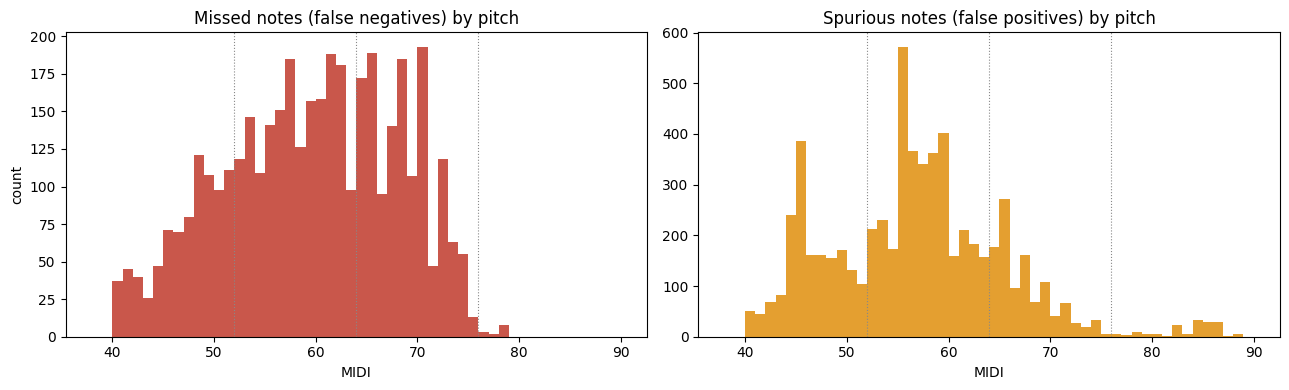

Missed by register:
 midi
mid (E3–D#4)         0.439
high (E4–D#5)        0.344
low (< E3)           0.213
very high (>= E5)    0.003

Spurious by register:
 midi
mid (E3–D#4)         0.530
low (< E3)           0.277
high (E4–D#5)        0.169
very high (>= E5)    0.024


In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
bins = range(BP_MIN_MIDI-2, BP_MAX_MIDI+3)
if len(missed_df):
    ax[0].hist(missed_df["midi"], bins=bins, color="#C0392B", alpha=0.85)
ax[0].set_title("Missed notes (false negatives) by pitch"); ax[0].set_xlabel("MIDI"); ax[0].set_ylabel("count")
if len(spurious_df):
    ax[1].hist(spurious_df["midi"], bins=bins, color="#E08E0B", alpha=0.85)
ax[1].set_title("Spurious notes (false positives) by pitch"); ax[1].set_xlabel("MIDI")
for a in ax:
    for mid in (52, 64, 76): a.axvline(mid, color="#888", ls=":", lw=0.8)
plt.tight_layout(); plt.show()

def reg(m):
    if m < 52: return "low (< E3)"
    if m < 64: return "mid (E3–D#4)"
    if m < 76: return "high (E4–D#5)"
    return "very high (>= E5)"
if len(missed_df): print("Missed by register:\n", missed_df["midi"].map(reg).value_counts(normalize=True).round(3).to_string())
if len(spurious_df): print("\nSpurious by register:\n", spurious_df["midi"].map(reg).value_counts(normalize=True).round(3).to_string())

## 3 · Octave harmonics — what share of false positives are ghosts

A spurious note exactly 12 or 24 semitones above a real note at the same instant is an overtone artifact, not a real note. This is the cheapest false-positive class to remove.

In [14]:
if len(spurious_df):
    share = spurious_df["octave_ghost"].mean()
    print(f"Of {len(spurious_df)} false positives, {share:.1%} are exact +12/+24 octaves of a real note at the same time.")
    by = spurious_df.groupby(spurious_df["is_solo"].map({True:"solo",False:"comp"}))["octave_ghost"].mean().round(3)
    display(by.rename("octave_ghost_share").to_frame())
    print("These are removable with an octave-harmonic filter (drop the upper octave when it's the quieter, "
          "simultaneous note). Everything else is a genuine spurious detection.")
else:
    print("No spurious notes recorded.")

Of 6358 false positives, 12.5% are exact +12/+24 octaves of a real note at the same time.


,octave_ghost_share
is_solo,
comp,0.107
solo,0.162


These are removable with an octave-harmonic filter (drop the upper octave when it's the quieter, simultaneous note). Everything else is a genuine spurious detection.


## 4 · Polyphony — recall on chords vs. single notes

Basic Pitch's known weak spot is dense polyphony. If recall collapses as onset-group size grows, your missed-note problem lives in comping.

,notes,recall
bucket,,
1 (single),3289,0.812
2,1764,0.719
3,1998,0.686
4,2516,0.639
5+,3656,0.630


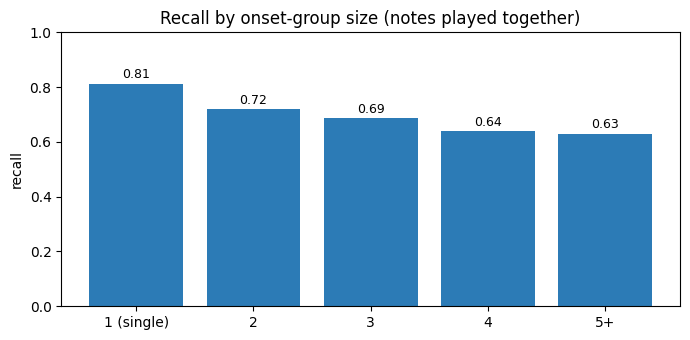

If recall drops sharply from single notes to chords, the misses are concentrated in polyphony (comping).


In [15]:
both = pd.concat([
    matched_df.assign(matched=1)[["group_size","matched","is_solo","is_comp"]],
    missed_df.assign(matched=0)[["group_size","matched","is_solo","is_comp"]],
], ignore_index=True)
both["bucket"] = both["group_size"].clip(upper=5).map({1:"1 (single)",2:"2",3:"3",4:"4",5:"5+"})
poly = both.groupby("bucket").agg(notes=("matched","size"), recall=("matched","mean")).reindex(["1 (single)","2","3","4","5+"]).dropna()
display(poly.assign(recall=poly["recall"].round(3)))

fig, ax = plt.subplots(figsize=(7,3.5))
ax.bar(poly.index, poly["recall"], color="#2C7BB6"); ax.set_ylim(0,1)
ax.set_title("Recall by onset-group size (notes played together)"); ax.set_ylabel("recall")
for i,v in enumerate(poly["recall"]): ax.text(i, v+0.02, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()
print("If recall drops sharply from single notes to chords, the misses are concentrated in polyphony (comping).")

## 5 · Onset timing & fragmentation — misses that aren't really the model

If Basic Pitch splits one sustained note into several onsets, or its timing drifts just past the match tolerance, those count as errors but are fixable in post-processing (merging / smoothing), not by a better model.

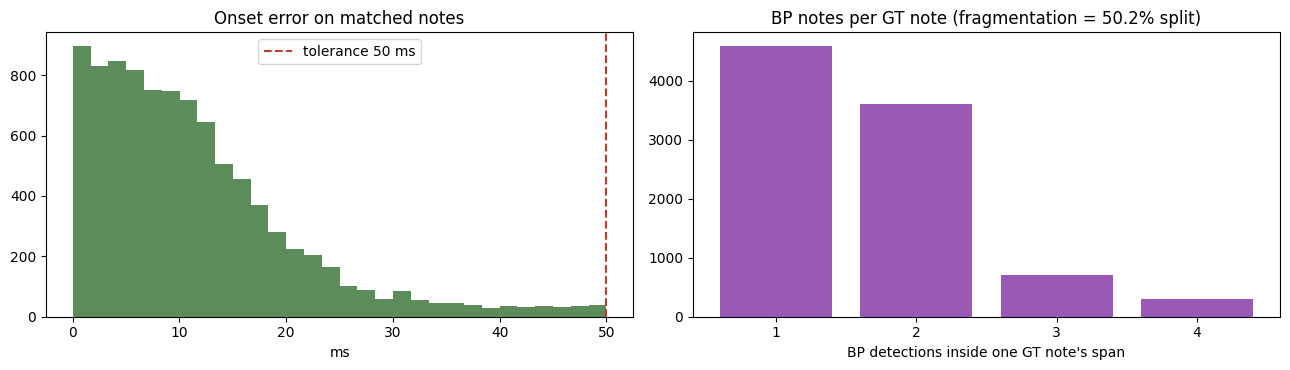

Median onset error: 9.3 ms.  50.2% of matched notes have >1 BP detection in their span (fragmentation).
A high fragmentation rate means merging fragmented onsets could recover precision/recall for free.


In [16]:
if len(matched_df):
    fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
    ax[0].hist(matched_df["onset_error"]*1000, bins=30, color="#5B8C5A")
    ax[0].axvline(ONSET_TOL*1000, color="#C0392B", ls="--", label=f"tolerance {ONSET_TOL*1000:.0f} ms")
    ax[0].set_title("Onset error on matched notes"); ax[0].set_xlabel("ms"); ax[0].legend()
    frag_rate = (matched_df["frag_count"] > 1).mean()
    fc = matched_df["frag_count"].clip(upper=4).value_counts().sort_index()
    ax[1].bar(fc.index.astype(str), fc.values, color="#9B59B6")
    ax[1].set_title(f"BP notes per GT note (fragmentation = {frag_rate:.1%} split)")
    ax[1].set_xlabel("BP detections inside one GT note's span")
    plt.tight_layout(); plt.show()
    print(f"Median onset error: {matched_df['onset_error'].median()*1000:.1f} ms.  "
          f"{frag_rate:.1%} of matched notes have >1 BP detection in their span (fragmentation).")
    print("A high fragmentation rate means merging fragmented onsets could recover precision/recall for free.")

## 6 · Amplitude threshold sweep — how many misses are just under the cutoff

We detected at a low threshold and kept all candidates with their amplitudes. Sweeping the keep-cutoff shows the recall/precision trade and whether real notes are dying just below your current 0.30.

2.8% of missed notes have a sub-threshold Basic Pitch detection at the right pitch/time (i.e. recoverable by lowering the amplitude cutoff).


,amp_cutoff,precision,recall,f1
0,0.10,0.5785,0.7030,0.6347
1,0.15,0.5785,0.7030,0.6347
2,0.20,0.5788,0.7029,0.6349
3,0.25,0.5822,0.7023,0.6367
4,0.30,0.5919,0.6973,0.6403
5,0.35,0.6125,0.6868,0.6475
6,0.40,0.6385,0.6663,0.6521
7,0.45,0.6656,0.6384,0.6517
8,0.50,0.6946,0.6012,0.6446


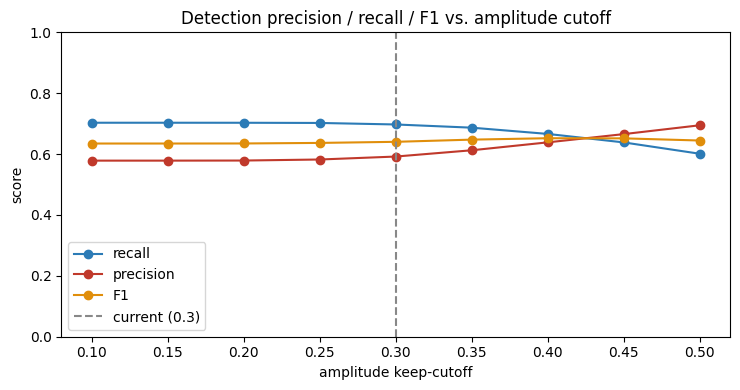

Note: BP was run at onset/frame threshold 0.3 - to probe even lower, drop BP_ONSET_THRESHOLD and clear the bp_raw_cache.


In [17]:
if len(missed_df):
    rec_frac = missed_df["recoverable"].mean()
    print(f"{rec_frac:.1%} of missed notes have a sub-threshold Basic Pitch detection at the right pitch/time "
          f"(i.e. recoverable by lowering the amplitude cutoff).")

# Sweep amplitude cutoff using cached raw notes (re-filter + re-match, no re-detection).
cuts = np.round(np.arange(0.10, 0.51, 0.05), 2)
sweep = []
for cut in cuts:
    g_tot = b_tot = m_tot = 0
    for rec, ap in paired:
        gt = rec["notes"]
        if not gt: continue
        raw = run_basic_pitch_raw(ap)
        bp = [n for n in raw if n["amplitude"] >= cut and BP_MIN_MIDI <= n["midi"] <= BP_MAX_MIDI]
        m, _, _ = match_detection(gt, bp)
        g_tot += len(gt); b_tot += len(bp); m_tot += len(m)
    rec_ = m_tot/g_tot if g_tot else 0; prec = m_tot/b_tot if b_tot else 0
    f1 = 2*prec*rec_/(prec+rec_) if (prec+rec_) else 0
    sweep.append({"amp_cutoff": cut, "precision": round(prec,4), "recall": round(rec_,4), "f1": round(f1,4)})
sweep_df = pd.DataFrame(sweep)
display(sweep_df)

fig, ax = plt.subplots(figsize=(7.5,4))
ax.plot(sweep_df["amp_cutoff"], sweep_df["recall"], "-o", label="recall", color="#2C7BB6")
ax.plot(sweep_df["amp_cutoff"], sweep_df["precision"], "-o", label="precision", color="#C0392B")
ax.plot(sweep_df["amp_cutoff"], sweep_df["f1"], "-o", label="F1", color="#E08E0B")
ax.axvline(AMP_THRESHOLD, color="#888", ls="--", label=f"current ({AMP_THRESHOLD})")
ax.set_xlabel("amplitude keep-cutoff"); ax.set_ylabel("score"); ax.set_ylim(0,1); ax.legend()
ax.set_title("Detection precision / recall / F1 vs. amplitude cutoff")
plt.tight_layout(); plt.show()
print("Note: BP was run at onset/frame threshold", BP_ONSET_THRESHOLD,
      "- to probe even lower, drop BP_ONSET_THRESHOLD and clear the bp_raw_cache.")

In [18]:
from collections import defaultdict

def _note_end(n):
    if n.get('end') is not None:
        return float(n['end'])
    return float(n['start']) + float(n.get('duration', 0.0) or 0.0)

def _finalize(base, start, end, amp, n_frag):
    out = dict(base)
    out['start'] = start; out['end'] = end
    out['duration'] = max(0.0, end - start)
    out['amplitude'] = amp; out['n_merged'] = n_frag
    return out

def merge_fragments(notes, merge_gap=0.07):
    """Collapse Basic Pitch fragments: consecutive same-pitch detections that overlap
    or sit within `merge_gap` seconds become one note (start=earliest onset,
    end=latest offset, amplitude=peak). Genuine repeats (gap > merge_gap) are kept."""
    if not notes:
        return []
    by_pitch = defaultdict(list)
    for n in notes:
        by_pitch[int(n['midi'])].append(n)
    merged = []
    for midi, group in by_pitch.items():
        group = sorted(group, key=lambda n: float(n['start']))
        cur = dict(group[0]); cur_start = float(cur['start'])
        cur_end = _note_end(cur); cur_amp = float(cur.get('amplitude', 0.0) or 0.0); n_frag = 1
        for n in group[1:]:
            s = float(n['start']); e = _note_end(n)
            if s <= cur_end + merge_gap:                 # overlap or tiny gap -> same note
                cur_end = max(cur_end, e)
                cur_amp = max(cur_amp, float(n.get('amplitude', 0.0) or 0.0)); n_frag += 1
            else:                                         # real gap -> new note
                merged.append(_finalize(cur, cur_start, cur_end, cur_amp, n_frag))
                cur = dict(n); cur_start = s; cur_end = e
                cur_amp = float(n.get('amplitude', 0.0) or 0.0); n_frag = 1
        merged.append(_finalize(cur, cur_start, cur_end, cur_amp, n_frag))
    merged.sort(key=lambda n: (float(n['start']), int(n['midi'])))
    return merged

MERGE_GAP = 0.07   # seconds; tune 0.05–0.10. Keep it below your typical repeated-note spacing.

In [19]:
def detection_stats(use_merge, merge_gap=MERGE_GAP):
    g = b = m = 0
    for rec, ap in paired:
        gt = rec['notes']
        if not gt: continue
        bp = pipeline_filter(run_basic_pitch_raw(ap))
        if use_merge:
            bp = merge_fragments(bp, merge_gap=merge_gap)
        matches, missed, spurious = match_detection(gt, bp)
        g += len(gt); b += len(bp); m += len(matches)
    rec_ = m/g if g else 0; prec = m/b if b else 0
    f1 = 2*prec*rec_/(prec+rec_) if (prec+rec_) else 0
    return {'bp_notes': b, 'matched': m, 'missed': g-m, 'spurious': b-m,
            'precision': round(prec, 4), 'recall': round(rec_, 4), 'f1': round(f1, 4)}

before, after = detection_stats(False), detection_stats(True)
import pandas as pd
display(pd.DataFrame({'before (raw BP)': before, 'after (merged)': after}).T)
d = before['spurious'] - after['spurious']
print(f"Spurious removed: {d} ({d/before['spurious']:.1%} of false positives)")
print(f"precision {before['precision']:.3f} -> {after['precision']:.3f} | "
      f"recall {before['recall']:.3f} -> {after['recall']:.3f} | "
      f"F1 {before['f1']:.3f} -> {after['f1']:.3f}")

,bp_notes,matched,missed,spurious,precision,recall,f1
before (raw BP),15579.0,9221.0,4002.0,6358.0,0.5919,0.6973,0.6403
after (merged),6802.0,4560.0,8663.0,2242.0,0.6704,0.3449,0.4554


Spurious removed: 4116 (64.7% of false positives)
precision 0.592 -> 0.670 | recall 0.697 -> 0.345 | F1 0.640 -> 0.455


## Takeaways — where to spend effort

Read the six sections together:

- **Recall vs. precision (1):** whichever is lower is the bigger lever. Low recall → chase missed notes; low precision → chase false positives.
- **Octave ghosts (3):** a high share here is the cheapest win — a smarter octave-harmonic filter removes them with no model change.
- **Polyphony (4):** if recall collapses on chords, your misses are a comping problem (Basic Pitch's known weakness), and that caps how far post-processing alone can take you.
- **Fragmentation / timing (5):** a high fragmentation rate or onset errors near the tolerance means many "misses" are alignment artifacts — merging fragmented onsets recovers them cheaply.
- **Threshold sweep (6):** if a big fraction of misses are recoverable just under 0.30, lowering the cutoff (and cleaning up the extra false positives downstream) is a quick recall gain.

Realistic expectation: post-processing (octave filter + onset merging + threshold tuning) gets the cheap points; the residual — genuine polyphony misses — is bounded by Basic Pitch itself. This notebook tells you how much of the gap is each.